In [1]:
#############################################
# 1. Import Libraries & Mount Drive
#############################################
import os
import time
import zipfile
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import drive

In [2]:
#############################################
# 2. Data Loading Function
#############################################
def get_data_loaders(data_dir, batch_size=32, img_size=(256, 256)):
    transform = transforms.Compose([
        transforms.Resize(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform)
    val_dataset = datasets.ImageFolder(os.path.join(data_dir, 'valid'), transform)
    test_dataset = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    return train_loader, val_loader, test_loader

In [3]:
#############################################
# 3. Define Training and Evaluation Functions
#############################################
def train_model(model, train_loader, val_loader, num_epochs, optimizer, criterion, device, scheduler=None):
    model.to(device)
    best_val_acc = 0.0
    best_model_path = 'best_model.pth'

    train_losses, train_accs = [], []
    val_losses, val_accs = [], []

    for epoch in range(1, num_epochs + 1):
        start_time = time.time()
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        epoch_loss = running_loss / total
        epoch_acc = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (preds == labels).sum().item()
        val_loss /= val_total
        val_acc = 100 * val_correct / val_total
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        epoch_time = time.time() - start_time
        samples_per_sec = total / epoch_time

        print(f"Epoch {epoch}/{num_epochs} | "
              f"Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% | "
              f"Time: {epoch_time:.2f}s | {samples_per_sec:.2f} samples/s")

        if scheduler:
            scheduler.step(epoch)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_model_path)
            print(f"Best model saved to {best_model_path}")

    # Plot training and validation loss curves
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.title('Loss Curves')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot training and validation accuracy curves
    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Accuracy')
    plt.plot(val_accs, label='Val Accuracy')
    plt.title('Accuracy Curves')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [4]:
def evaluate_model(model, test_loader, device, class_names, model_path='best_model.pth'):
    """
    Evaluates the model on the test dataset.

    Args:
        model: The model to evaluate.
        test_loader: DataLoader for the test dataset.
        device: The device to use for computation (e.g., 'cuda' or 'cpu').
        class_names: A list of class names.
        model_path: Path to the model file to load. Defaults to 'best_model.pth'.
    """
    model.load_state_dict(torch.load(model_path))  # Load from the specified path
    model.to(device)
    model.eval()

    y_true, y_pred = [], []
    total, correct = 0, 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    test_acc = 100 * correct / total
    print(f"\nTest Accuracy: {test_acc:.2f}%")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

In [5]:
def plot_true_vs_predicted(model, test_loader, device, class_names, num_examples=16):
    model.load_state_dict(torch.load('best_model.pth'))
    model.to(device).eval()

    # Get a batch of test data
    inputs, labels = next(iter(test_loader))
    inputs = inputs.to(device)

    # Get predictions
    with torch.no_grad():
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

    # Denormalize images for visualization
    def denormalize(image):
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)
        return image * std + mean

    # Plot true vs predicted images in a 4x4 grid
    plt.figure(figsize=(12, 12))  # Adjust figure size for 16 images
    for idx in range(num_examples):
        img = denormalize(inputs[idx]).cpu().permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)  # Clip to valid image range

        plt.subplot(4, 4, idx + 1)  # 4 rows, 4 columns
        plt.imshow(img)
        plt.title(f"True: {class_names[labels[idx]]}\nPred: {class_names[predicted[idx]]}", fontsize=8)  # Smaller font size
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [6]:
# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
#############################################
# 4. Set Paths, Extract Dataset & Create Data Loaders
#############################################
dataset_path = '/content/drive/MyDrive/My Datasets/Tea_Betel_Leaf_Final_Dataset(1).zip'
extract_path = '/content/data'
batch_size = 16
img_size = (256, 256)
num_classes = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
data_dir = os.path.join(extract_path, 'Tea_Betel_Leaf_Final_Dataset')
train_loader, val_loader, test_loader = get_data_loaders(data_dir, batch_size, img_size)
class_names = train_loader.dataset.classes
print("Classes:", class_names)

Classes: ['betel_Bacterial Leaf Disease', 'betel_Dried Leaf', 'betel_Fungal Brown Spot Disease', 'betel_Healthy Leaf', 'tea_algal_spot', 'tea_brown_blight', 'tea_gray_blight', 'tea_healthy', 'tea_helopeltis', 'tea_red_spot']


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [8]:
#############################################
# 5. Load Pre-trained ShuffleNet V2 & Modify Classifier
#############################################
from torchvision.models import shufflenet_v2_x1_0
# Load pre-trained ShuffleNet V2
model = shufflenet_v2_x1_0(pretrained=True)
# Replace final fully-connected layer to match number of classes
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

# Freeze feature extractor layers
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1`. You can also use `weights=ShuffleNet_V2_X1_0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x1-5666bf0f80.pth
100%|██████████| 8.79M/8.79M [00:00<00:00, 68.8MB/s]


In [9]:
!pip install torchinfo

In [10]:
from torchinfo import summary

In [11]:
# Analyze the model after Stage 1 training
print("\nModel Analysis:")
summary(model, input_size=(1, 3, img_size[0], img_size[1]))


Model Analysis:


Layer (type:depth-idx)                   Output Shape              Param #
ShuffleNetV2                             [1, 10]                   --
├─Sequential: 1-1                        [1, 24, 128, 128]         --
│    └─Conv2d: 2-1                       [1, 24, 128, 128]         (648)
│    └─BatchNorm2d: 2-2                  [1, 24, 128, 128]         (48)
│    └─ReLU: 2-3                         [1, 24, 128, 128]         --
├─MaxPool2d: 1-2                         [1, 24, 64, 64]           --
├─Sequential: 1-3                        [1, 116, 32, 32]          --
│    └─InvertedResidual: 2-4             [1, 116, 32, 32]          --
│    │    └─Sequential: 3-1              [1, 58, 32, 32]           (1,772)
│    │    └─Sequential: 3-2              [1, 58, 32, 32]           (5,626)
│    └─InvertedResidual: 2-5             [1, 116, 32, 32]          --
│    │    └─Sequential: 3-3              [1, 58, 32, 32]           (7,598)
│    └─InvertedResidual: 2-6             [1, 116, 32, 32]        


Stage 1: Training only SqueezeNet classifier layers
Epoch 1/40 | Train Loss: 2.1459 Acc: 58.14% | Val Loss: 1.9777 Acc: 81.46% | Time: 34.90s | 197.88 samples/s
Best model saved to best_model.pth


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 2/40 | Train Loss: 1.8762 Acc: 81.77% | Val Loss: 1.7289 Acc: 85.22% | Time: 22.83s | 302.51 samples/s
Best model saved to best_model.pth
Epoch 3/40 | Train Loss: 1.6597 Acc: 84.55% | Val Loss: 1.5174 Acc: 86.84% | Time: 21.58s | 320.01 samples/s
Best model saved to best_model.pth
Epoch 4/40 | Train Loss: 1.4794 Acc: 86.03% | Val Loss: 1.3479 Acc: 87.31% | Time: 24.57s | 281.07 samples/s
Best model saved to best_model.pth
Epoch 5/40 | Train Loss: 1.3373 Acc: 85.81% | Val Loss: 1.2114 Acc: 87.17% | Time: 22.74s | 303.72 samples/s
Epoch 6/40 | Train Loss: 1.2113 Acc: 87.07% | Val Loss: 1.0973 Acc: 87.44% | Time: 21.58s | 320.09 samples/s
Best model saved to best_model.pth
Epoch 7/40 | Train Loss: 1.1173 Acc: 86.91% | Val Loss: 1.0103 Acc: 88.25% | Time: 23.14s | 298.40 samples/s
Best model saved to best_model.pth
Epoch 8/40 | Train Loss: 1.0312 Acc: 87.55% | Val Loss: 0.9368 Acc: 87.31% | Time: 21.75s | 317.52 samples/s
Epoch 9/40 | Train Loss: 0.9615 Acc: 87.60% | Val Loss: 0.8695

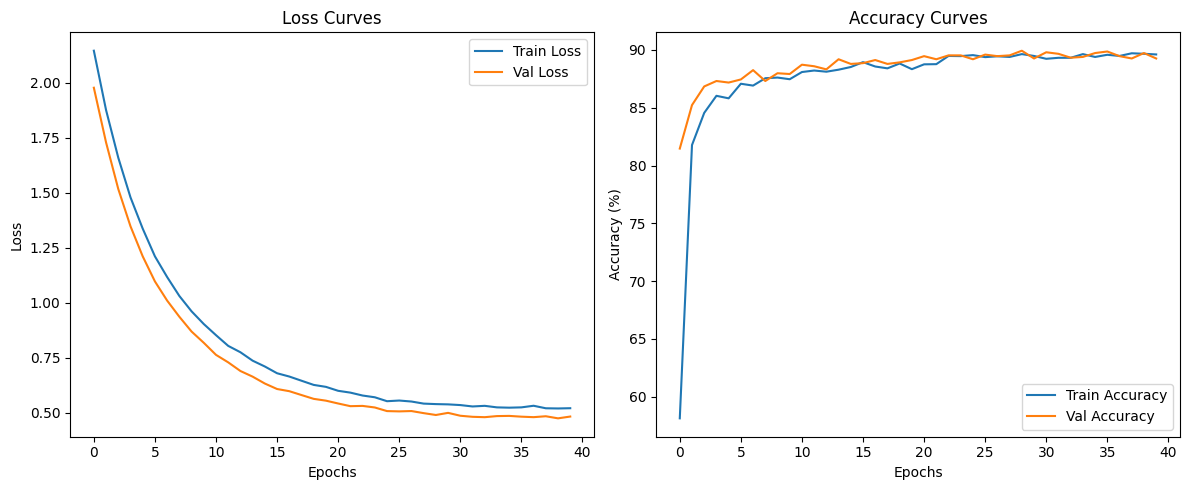

In [12]:
# Define loss and optimizer (only classifier params will be updated)
criterion = nn.CrossEntropyLoss()
optimizer_stage1 = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=3e-4)
# Cosine annealing scheduler (40 epochs)
scheduler = CosineAnnealingLR(optimizer_stage1, T_max=40)

# Stage 1: train only the classification layer
print("\nStage 1: Training only SqueezeNet classifier layers")
train_model(model, train_loader, val_loader,
            num_epochs=40,
            optimizer=optimizer_stage1,
            criterion=criterion,
            device=device,
            scheduler=scheduler)


Test Accuracy: 90.76%

Classification Report:
                                 precision    recall  f1-score   support

   betel_Bacterial Leaf Disease       0.87      0.81      0.84       148
               betel_Dried Leaf       1.00      0.99      1.00       148
betel_Fungal Brown Spot Disease       0.94      0.97      0.95       148
             betel_Healthy Leaf       0.83      0.87      0.85       148
                 tea_algal_spot       0.96      0.97      0.97       150
               tea_brown_blight       0.84      0.87      0.85       130
                tea_gray_blight       0.92      0.85      0.88       150
                    tea_healthy       0.84      0.97      0.90       150
                 tea_helopeltis       0.95      0.84      0.89       150
                   tea_red_spot       0.93      0.93      0.93       150

                       accuracy                           0.91      1472
                      macro avg       0.91      0.91      0.91      1472
  

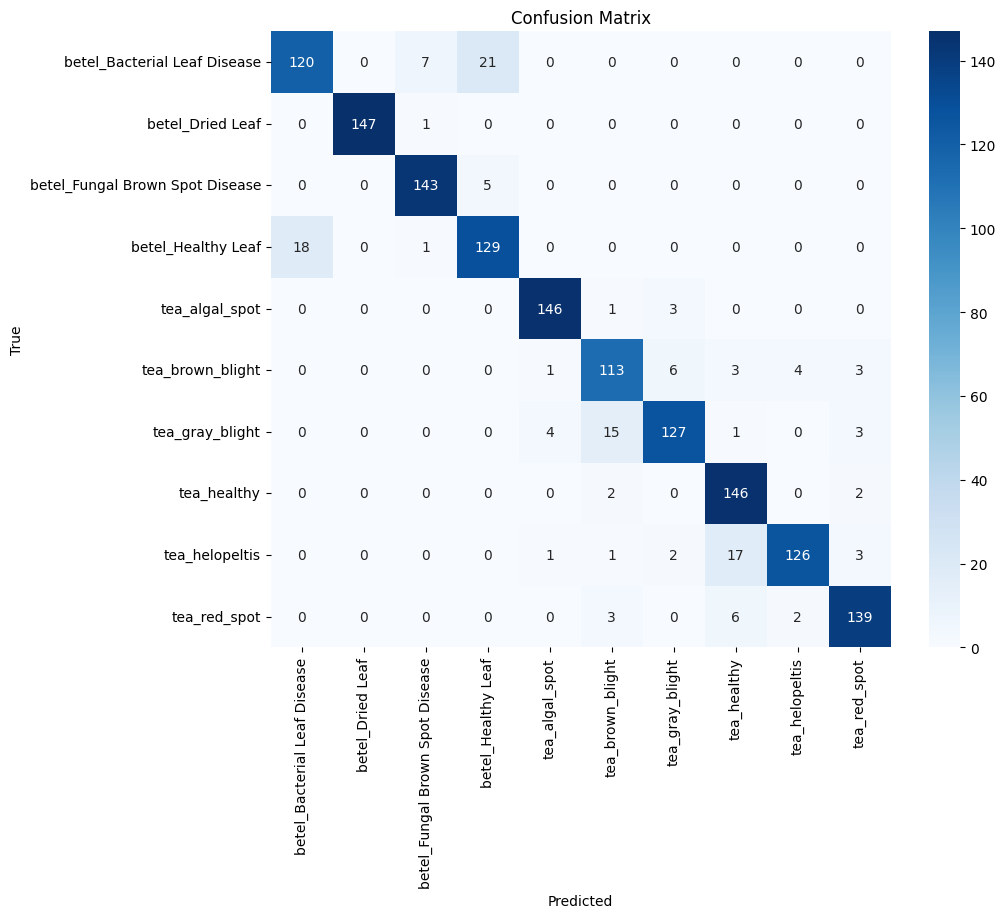

In [13]:
evaluate_model(model, test_loader, device, class_names)

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


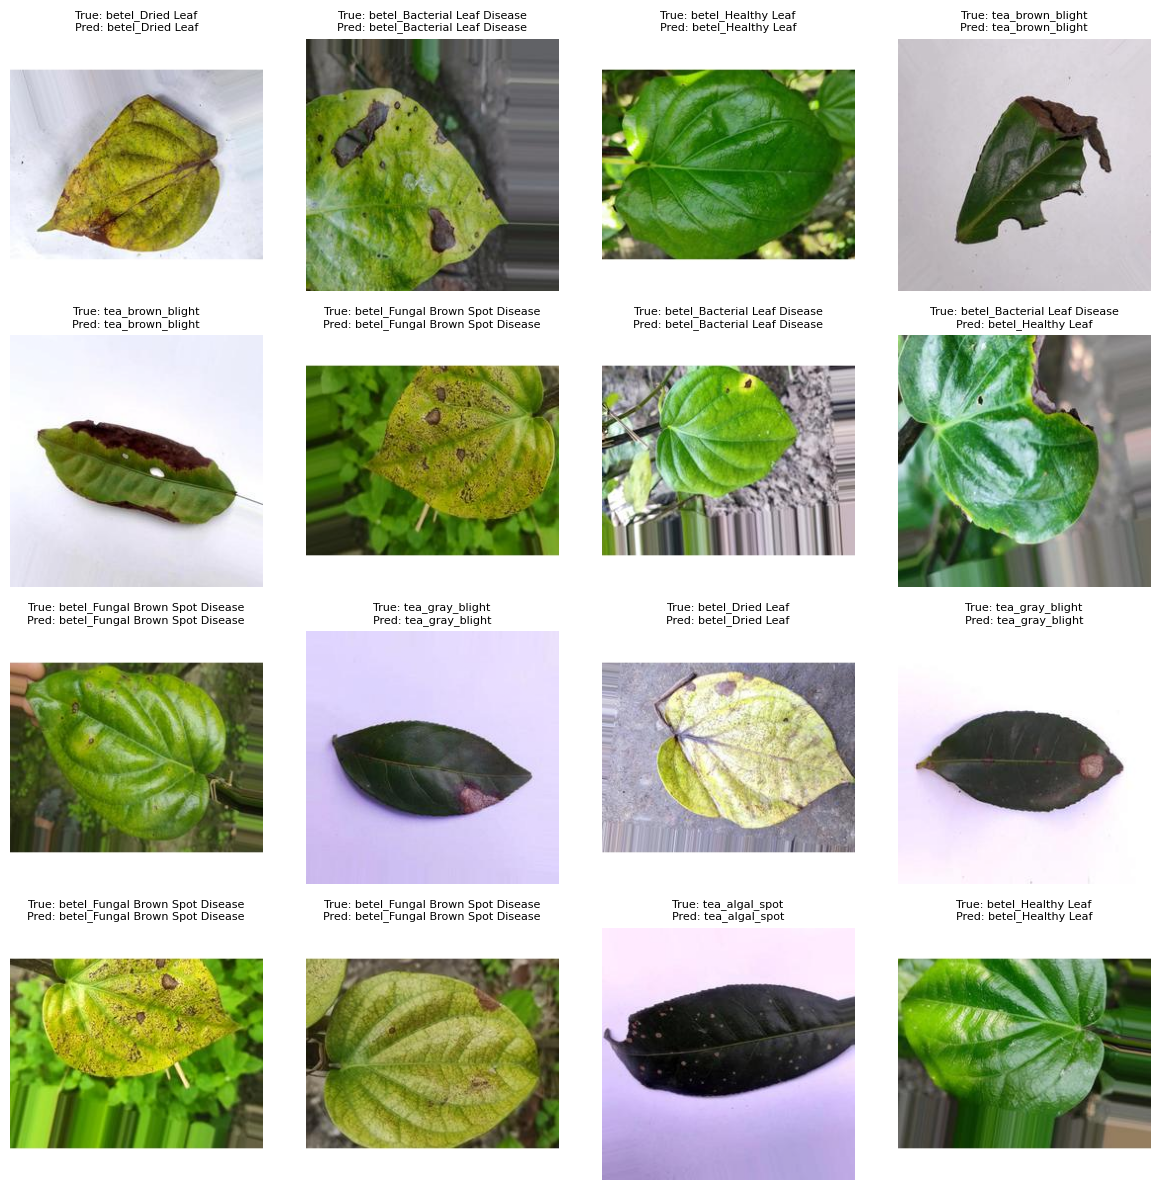

In [14]:
plot_true_vs_predicted(model, test_loader, device, class_names)

In [15]:
#############################################
# 7. Stage 2: Fine-tune by Unfreezing Last 20 Layers
#############################################
print("\nStage 2: Fine-tuning last 20 layers")
# Freeze all parameters first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the last 20 parameters (from the list of named parameters)
named_params = list(model.named_parameters())
for name, param in named_params[-20:]:
    param.requires_grad = True
    # Uncomment the next line to see which layers are being unfrozen
    print(f"Unfreezing: {name}")


Stage 2: Fine-tuning last 20 layers
Unfreezing: stage4.2.branch2.3.weight
Unfreezing: stage4.2.branch2.4.weight
Unfreezing: stage4.2.branch2.4.bias
Unfreezing: stage4.2.branch2.5.weight
Unfreezing: stage4.2.branch2.6.weight
Unfreezing: stage4.2.branch2.6.bias
Unfreezing: stage4.3.branch2.0.weight
Unfreezing: stage4.3.branch2.1.weight
Unfreezing: stage4.3.branch2.1.bias
Unfreezing: stage4.3.branch2.3.weight
Unfreezing: stage4.3.branch2.4.weight
Unfreezing: stage4.3.branch2.4.bias
Unfreezing: stage4.3.branch2.5.weight
Unfreezing: stage4.3.branch2.6.weight
Unfreezing: stage4.3.branch2.6.bias
Unfreezing: conv5.0.weight
Unfreezing: conv5.1.weight
Unfreezing: conv5.1.bias
Unfreezing: fc.weight
Unfreezing: fc.bias


In [16]:
# Analyze the model after Stage 2 training
print("\nModel Analysis at Stage 2 Training:")
summary(model, input_size=(1, 3, img_size[0], img_size[1]))


Model Analysis at Stage 2 Training:


Layer (type:depth-idx)                   Output Shape              Param #
ShuffleNetV2                             [1, 10]                   --
├─Sequential: 1-1                        [1, 24, 128, 128]         --
│    └─Conv2d: 2-1                       [1, 24, 128, 128]         (648)
│    └─BatchNorm2d: 2-2                  [1, 24, 128, 128]         (48)
│    └─ReLU: 2-3                         [1, 24, 128, 128]         --
├─MaxPool2d: 1-2                         [1, 24, 64, 64]           --
├─Sequential: 1-3                        [1, 116, 32, 32]          --
│    └─InvertedResidual: 2-4             [1, 116, 32, 32]          --
│    │    └─Sequential: 3-1              [1, 58, 32, 32]           (1,772)
│    │    └─Sequential: 3-2              [1, 58, 32, 32]           (5,626)
│    └─InvertedResidual: 2-5             [1, 116, 32, 32]          --
│    │    └─Sequential: 3-3              [1, 58, 32, 32]           (7,598)
│    └─InvertedResidual: 2-6             [1, 116, 32, 32]        

Epoch 1/40 | Train Loss: 0.2448 Acc: 92.27% | Val Loss: 0.1552 Acc: 94.43% | Time: 23.09s | 299.08 samples/s
Best model saved to best_model.pth


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 2/40 | Train Loss: 0.1238 Acc: 96.06% | Val Loss: 0.1191 Acc: 95.50% | Time: 23.18s | 297.87 samples/s
Best model saved to best_model.pth
Epoch 3/40 | Train Loss: 0.0869 Acc: 97.38% | Val Loss: 0.1227 Acc: 95.70% | Time: 21.62s | 319.39 samples/s
Best model saved to best_model.pth
Epoch 4/40 | Train Loss: 0.0581 Acc: 98.32% | Val Loss: 0.1063 Acc: 96.10% | Time: 23.32s | 296.12 samples/s
Best model saved to best_model.pth
Epoch 5/40 | Train Loss: 0.0443 Acc: 98.73% | Val Loss: 0.0956 Acc: 96.51% | Time: 23.25s | 296.97 samples/s
Best model saved to best_model.pth
Epoch 6/40 | Train Loss: 0.0377 Acc: 98.90% | Val Loss: 0.0945 Acc: 96.51% | Time: 21.85s | 316.13 samples/s
Epoch 7/40 | Train Loss: 0.0293 Acc: 99.30% | Val Loss: 0.0869 Acc: 97.18% | Time: 23.24s | 297.11 samples/s
Best model saved to best_model.pth
Epoch 8/40 | Train Loss: 0.0263 Acc: 99.23% | Val Loss: 0.0895 Acc: 96.78% | Time: 23.28s | 296.65 samples/s
Epoch 9/40 | Train Loss: 0.0195 Acc: 99.54% | Val Loss: 0.1046

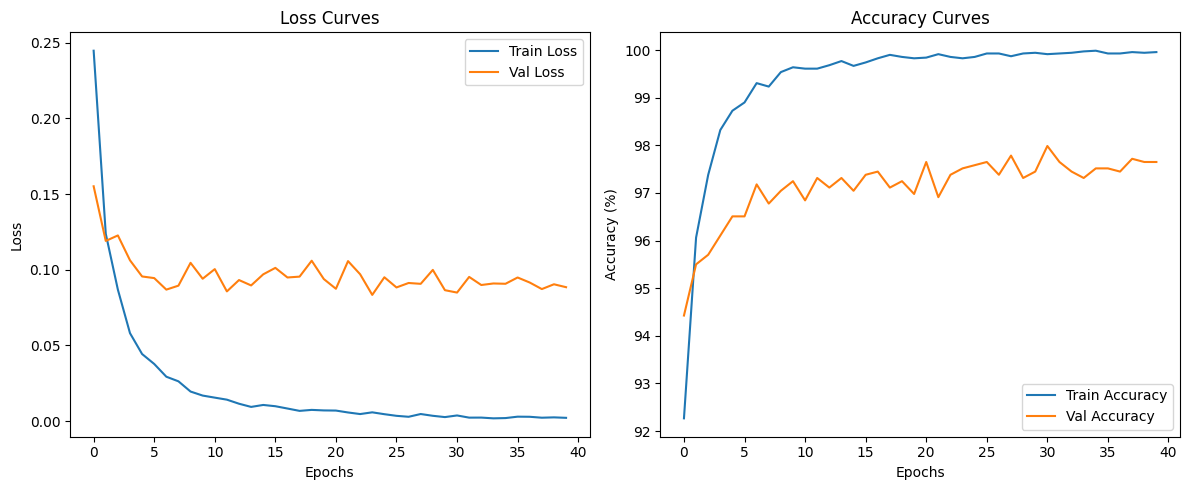

In [17]:
params_to_update = [param for param in model.parameters() if param.requires_grad]
optimizer_stage2 = optim.Adam(params_to_update, lr=3e-4)
scheduler = CosineAnnealingLR(optimizer_stage2, T_max=40)
train_model(model, train_loader, val_loader, num_epochs=40, optimizer=optimizer_stage2,
            criterion=criterion, device=device, scheduler=scheduler)


Test Accuracy: 98.17%

Classification Report:
                                 precision    recall  f1-score   support

   betel_Bacterial Leaf Disease       0.94      0.97      0.95       148
               betel_Dried Leaf       1.00      1.00      1.00       148
betel_Fungal Brown Spot Disease       1.00      1.00      1.00       148
             betel_Healthy Leaf       0.97      0.93      0.95       148
                 tea_algal_spot       1.00      1.00      1.00       150
               tea_brown_blight       0.94      1.00      0.97       130
                tea_gray_blight       1.00      0.95      0.97       150
                    tea_healthy       0.98      0.99      0.99       150
                 tea_helopeltis       0.99      0.97      0.98       150
                   tea_red_spot       0.99      1.00      1.00       150

                       accuracy                           0.98      1472
                      macro avg       0.98      0.98      0.98      1472
  

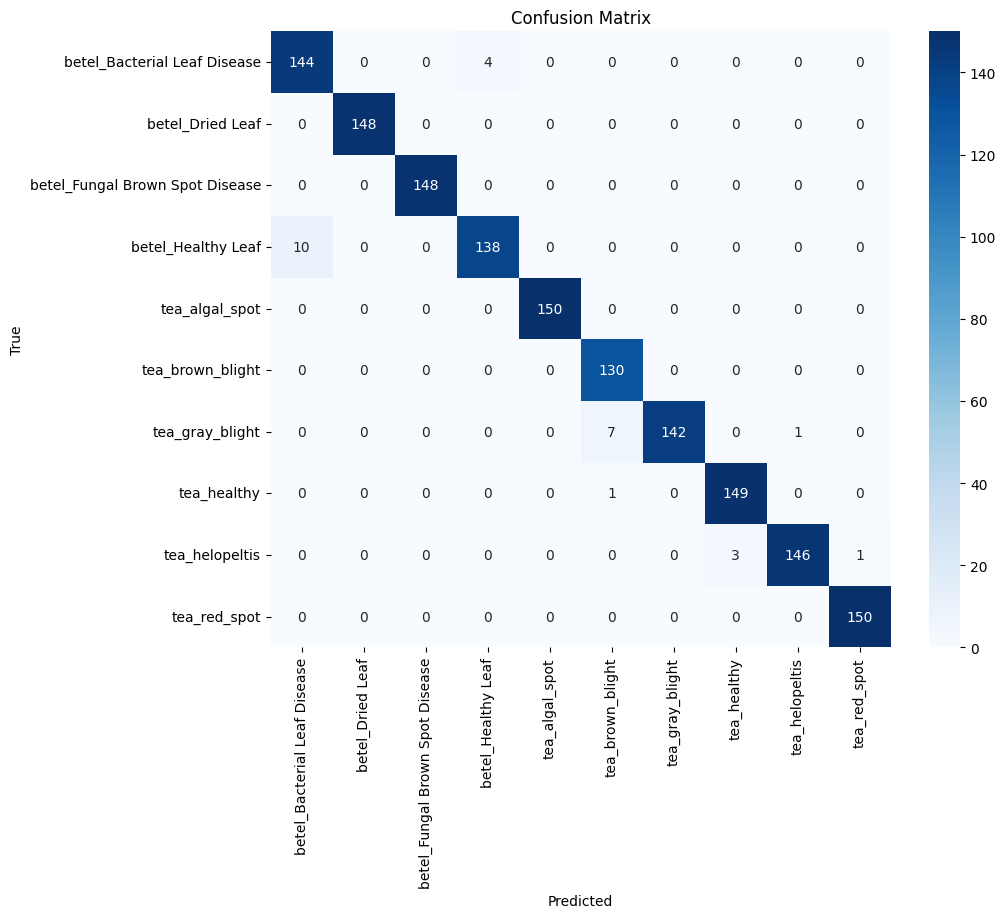

In [18]:
evaluate_model(model, test_loader, device, class_names)

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


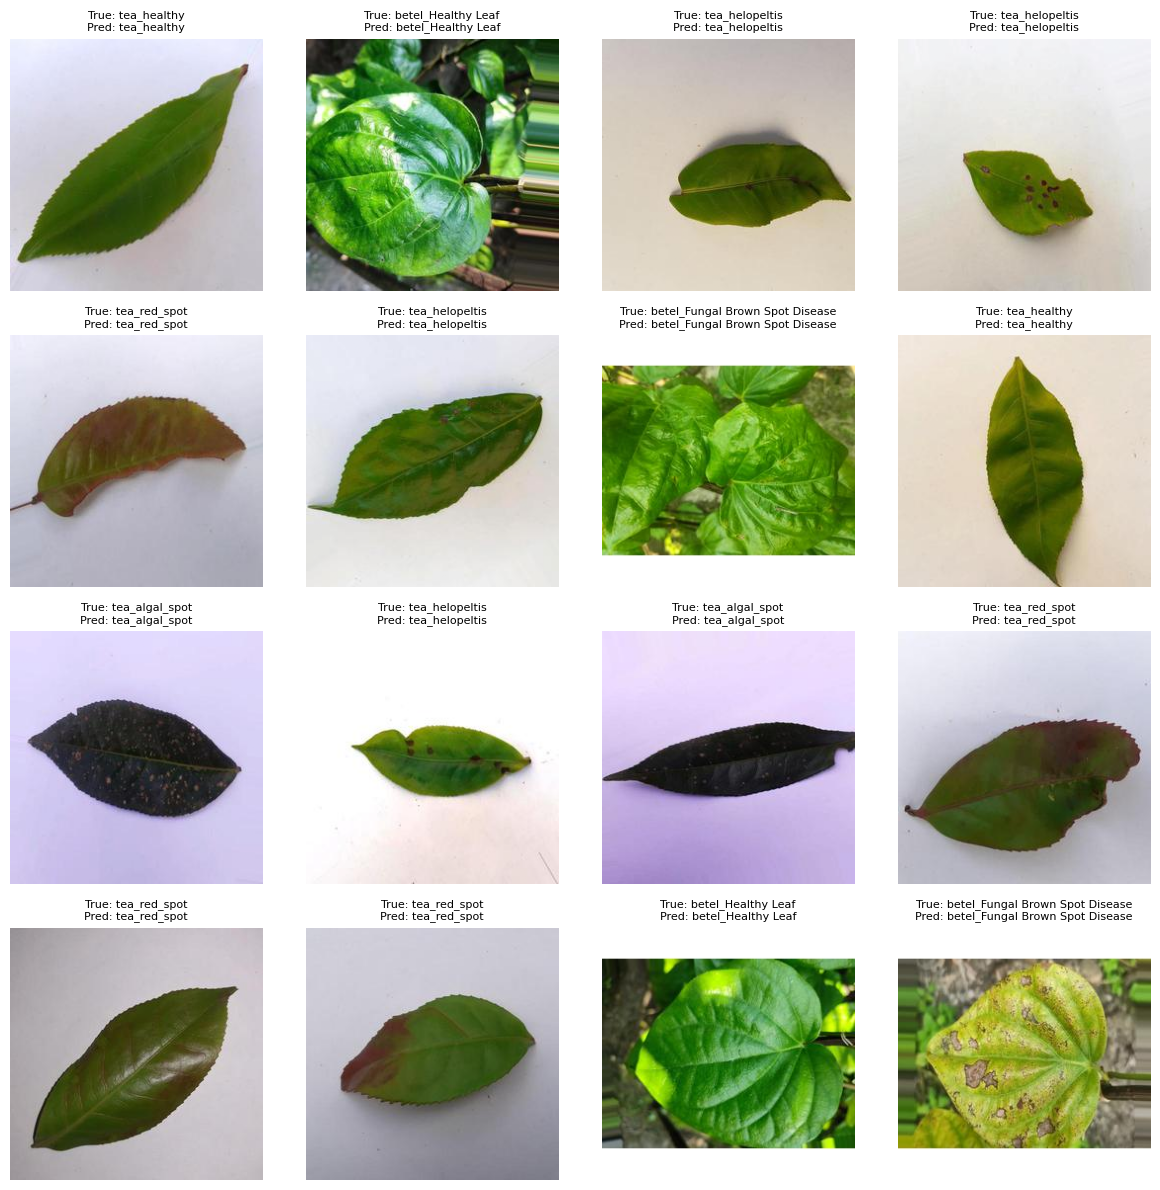

In [19]:
plot_true_vs_predicted(model, test_loader, device, class_names)